# GRADE — figures for both encoders

Rebuilds every chart the paper uses, for `deberta-v3-small` and
`roberta-base`, from results already on disk. No training happens here
except the optional LIME section at the end.

**Inputs**

| Path | Used for |
|---|---|
| `results/loto_runs.csv` | per-fold accuracy, recall, ROC-AUC, error rates |
| `results/loto_baselines.csv` | length-only and word-frequency controls |
| `results/loto_predictions/` | per-essay `prob_ai`, for ROC / thresholds |
| `results/rq2_markers_within_grade.csv` | formality mechanism |
| `results/rq2_lime_tokens.csv` | LIME tokens already computed for DeBERTa |
| `datasets/Persuade 2.0/…csv` | grades and writer characteristics |

**Outputs** land in `results/figures/both/` as PDF (for LaTeX) and PNG.


## 1 · Setup

In [1]:

import os, glob, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix

REPO    = os.path.abspath('..')
DATA    = os.path.join(REPO, 'data')
LOTO    = os.path.join(DATA, 'loto')
RESULTS = os.path.join(REPO, 'results')
PREDS   = os.path.join(RESULTS, 'loto_predictions')
FIGS    = os.path.join(RESULTS, 'figures', 'both')
os.makedirs(FIGS, exist_ok=True)

PERSUADE = os.path.join(REPO, 'datasets', 'Persuade 2.0',
                        'persuade_2.0_human_scores_demo_id_github.csv')

SEED   = 42
MODELS = ['deberta-v3', 'roberta']
NICE   = {'deberta-v3': 'DeBERTa-v3-small', 'roberta': 'RoBERTa-base'}

# one colour per model, used everywhere
C = {'deberta-v3': '#1E6CDB', 'roberta': '#E67E22'}
CTRL_TFIDF, CTRL_LEN, DARK, GREY = '#C0392B', '#95A5A6', '#2C3E50', '#B0B0B0'

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 400,
    'font.size': 8, 'axes.titlesize': 9, 'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#EFEFEF', 'grid.linewidth': 0.6,
    'axes.axisbelow': True, 'figure.autolayout': False,
})

SHORT = {
    'Does the electoral college work?': 'Electoral college',
    'Mandatory extracurricular activities': 'Mandatory extracurriculars',
    '"A Cowboy Who Rode the Waves"': 'A Cowboy Who Rode the Waves',
    'Grades for extracurricular activities': 'Grades for extracurriculars',
    'Facial action coding system': 'Facial action coding',
}
short = lambda t: SHORT.get(t, t)

def save(fig, name):
    """Write one figure as PDF and PNG, then report the paths."""
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(FIGS, name + '.' + ext), bbox_inches='tight')
    print('saved  %s.pdf  %s.png' % (name, name))

print('figures ->', FIGS)

figures -> C:\Users\user\Documents\GRADE STUDY\Education Domain\results\figures\both


### Load the results

In [2]:

runs = pd.read_csv(os.path.join(RESULTS, 'loto_runs.csv'))
base = pd.read_csv(os.path.join(RESULTS, 'loto_baselines.csv'))

runs = runs[runs.seed == SEED]
present = sorted(runs.model.unique())
print('models in loto_runs.csv:', present)
for m in MODELS:
    n = runs[runs.model == m].fold.nunique()
    print('  %-12s %2d / 15 folds' % (m, n))

tfidf = base[base.baseline == 'tfidf'][['fold', 'accuracy']].rename(
    columns={'accuracy': 'tfidf'})
length = base[base.baseline == 'length_only'][['fold', 'accuracy']].rename(
    columns={'accuracy': 'length'})

# one tidy frame: one row per (model, fold)
wide = runs[['model', 'fold', 'held_out_topic', 'accuracy', 'recall',
             'roc_auc', 'fpr', 'fnr', 'n_test']].copy()
wide = wide.merge(tfidf, on='fold').merge(length, on='fold')
wide['margin_tfidf']  = wide.accuracy - wide.tfidf
wide['margin_length'] = wide.accuracy - wide.length
wide['topic'] = wide.held_out_topic.map(short)
wide = wide.sort_values(['model', 'fold']).reset_index(drop=True)

pd.set_option('display.width', 200)
print()
print(wide.groupby('model')[['accuracy', 'roc_auc', 'margin_tfidf']].mean().round(4))
wide.head()

models in loto_runs.csv: ['deberta-v3', 'roberta']
  deberta-v3   15 / 15 folds
  roberta      15 / 15 folds

            accuracy  roc_auc  margin_tfidf
model                                      
deberta-v3    0.9811   0.9991       -0.0076
roberta       0.9818   0.9993       -0.0070


,model,fold,held_out_topic,accuracy,recall,roc_auc,fpr,fnr,n_test,tfidf,length,margin_tfidf,margin_length,topic
0,deberta-v3,0,Distance learning,0.987946,0.987019,0.998470,0.011127,0.012981,4314,0.994439,0.763670,-0.006493,0.224276,Distance learning
1,deberta-v3,1,Car-free cities,0.996099,0.998537,0.999892,0.006338,0.001463,4102,0.993177,0.549708,0.002922,0.446392,Car-free cities
2,deberta-v3,2,Does the electoral college work?,0.994767,0.999419,0.999984,0.009884,0.000581,3440,0.989535,0.550000,0.005233,0.444767,Electoral college
3,deberta-v3,3,Seeking multiple opinions,0.960052,0.991624,0.996843,0.071521,0.008376,3104,0.981959,0.719072,-0.021907,0.240979,Seeking multiple opinions
4,deberta-v3,4,Mandatory extracurricular activities,0.983642,0.994310,0.998186,0.027027,0.005690,2812,0.990043,0.742532,-0.006401,0.241110,Mandatory extracurriculars


### Load the per-essay predictions

One file per (fold, model). `prob_ai` is the score the ROC curves and the
threshold analysis need.


In [3]:

def load_preds(model, seed=SEED):
    """Every fold's predictions for one model, concatenated."""
    rows = []
    for path in sorted(glob.glob(os.path.join(
            PREDS, 'preds_f*_%s_seed%d.csv' % (model, seed)))):
        fold = int(os.path.basename(path).split('_')[1][1:])
        d = pd.read_csv(path)
        d['fold'] = fold
        d['model'] = model
        rows.append(d)
    if not rows:
        return pd.DataFrame(columns=['uid', 'label', 'pred', 'prob_ai', 'fold', 'model'])
    return pd.concat(rows, ignore_index=True)

preds = pd.concat([load_preds(m) for m in MODELS], ignore_index=True)
topics = wide[['fold', 'held_out_topic', 'topic']].drop_duplicates('fold')
preds = preds.merge(topics, on='fold', how='left')

print(preds.groupby('model').agg(folds=('fold', 'nunique'), essays=('uid', 'size')))
preds.head()

            folds  essays
model                    
deberta-v3     15   28366
roberta        15   28366


,uid,label,pred,prob_ai,fold,model,held_out_topic,topic
0,f2f704ec9e5b6c456ad8441da603725b,1,1,0.999992,0,deberta-v3,Distance learning,Distance learning
1,ac37b9df9e2d45a945e97ab408264c11,1,1,0.999992,0,deberta-v3,Distance learning,Distance learning
2,26dd825a5cb23f2e6d1767afa17363fa,1,1,0.999963,0,deberta-v3,Distance learning,Distance learning
3,33e046fb0b05dcb6a28b2852104430fe,0,0,0.000402,0,deberta-v3,Distance learning,Distance learning
4,65ecc5989db168833f061c9b39c6041b,0,0,0.000297,0,deberta-v3,Distance learning,Distance learning


## 2 · RQ1 — transfer to an unseen assignment

### 2.1 Accuracy per fold, both encoders, against both controls


saved  rq1_accuracy_per_fold.pdf  rq1_accuracy_per_fold.png


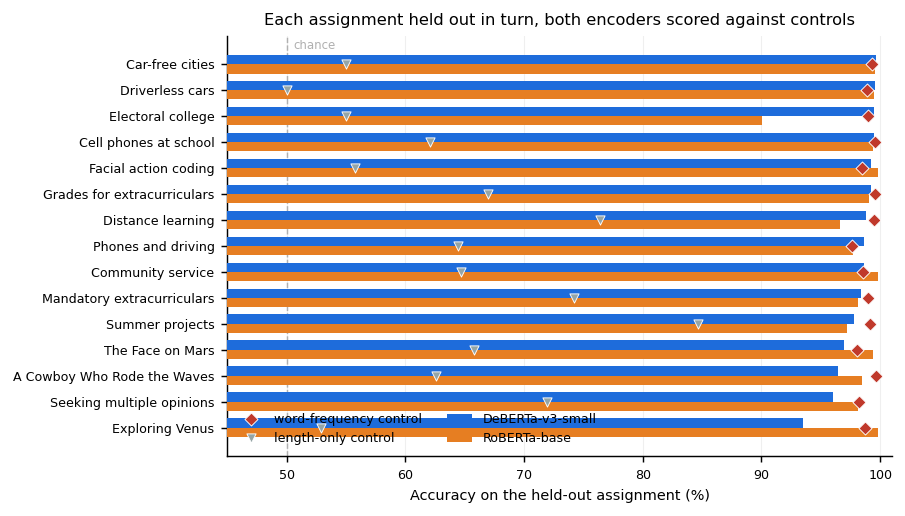

In [4]:

piv = wide.pivot(index='fold', columns='model', values='accuracy')
order = wide[wide.model == MODELS[0]].sort_values('accuracy').fold.tolist()
labels = topics.set_index('fold').loc[order, 'topic']

fig, ax = plt.subplots(figsize=(6.6, 4.2))
y = np.arange(len(order))
h = 0.36
for k, m in enumerate(MODELS):
    if m not in piv.columns:
        continue
    ax.barh(y + (0.5 - k) * h, piv.loc[order, m] * 100, height=h,
            color=C[m], label=NICE[m], zorder=3)

ctrl = wide.drop_duplicates('fold').set_index('fold')
ax.scatter(ctrl.loc[order, 'tfidf'] * 100, y, marker='D', s=26, zorder=5,
           color=CTRL_TFIDF, edgecolor='white', linewidth=0.5,
           label='word-frequency control')
ax.scatter(ctrl.loc[order, 'length'] * 100, y, marker='v', s=26, zorder=5,
           color=CTRL_LEN, edgecolor='white', linewidth=0.5,
           label='length-only control')

ax.axvline(50, color=GREY, ls='--', lw=0.8, zorder=1)
ax.text(50.6, len(order) - 0.4, 'chance', fontsize=6.5, color=GREY)
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel('Accuracy on the held-out assignment (%)')
ax.set_xlim(45, 101)
ax.grid(axis='y', visible=False)
ax.legend(loc='lower left', frameon=False, ncol=2)
ax.set_title('Each assignment held out in turn, both encoders scored against controls')
save(fig, 'rq1_accuracy_per_fold')
plt.show()

### 2.2 Margin over the word-frequency control

The bar the paper's argument rests on: positive means the detector beat a
method that cannot recognise authorship, negative means it did not.


saved  rq1_margin_vs_control.pdf  rq1_margin_vs_control.png


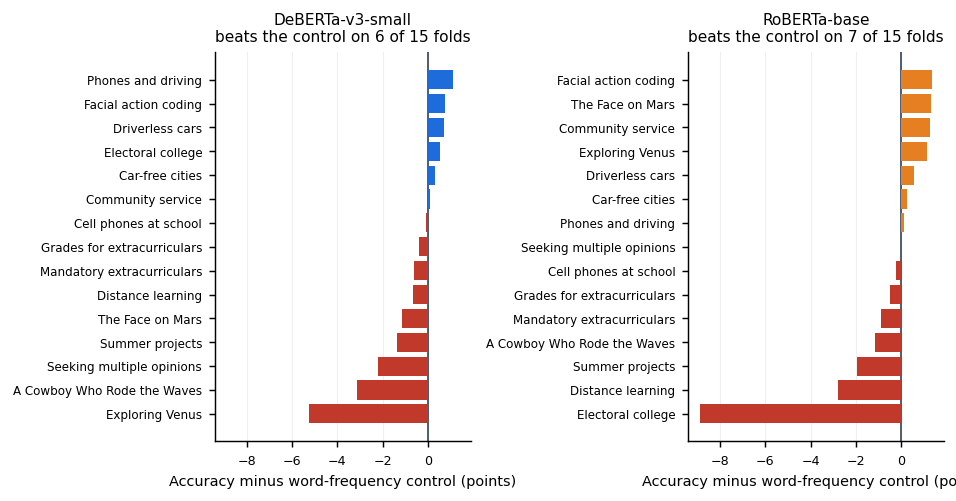

DeBERTa-v3-small mean margin -0.76 pts, beats control on 6/15 folds
RoBERTa-base mean margin -0.70 pts, beats control on 7/15 folds


In [5]:

fig, axes = plt.subplots(1, len(MODELS), figsize=(7.4, 3.9), sharex=True)
axes = np.atleast_1d(axes)

for ax, m in zip(axes, MODELS):
    d = wide[wide.model == m].sort_values('margin_tfidf')
    if d.empty:
        continue
    cols = [C[m] if v > 0 else CTRL_TFIDF for v in d.margin_tfidf]
    ax.barh(np.arange(len(d)), d.margin_tfidf * 100, color=cols, zorder=3)
    ax.axvline(0, color=DARK, lw=0.9)
    ax.set_yticks(np.arange(len(d)))
    ax.set_yticklabels(d.topic, fontsize=6.6)
    ax.grid(axis='y', visible=False)
    won = int((d.margin_tfidf > 0).sum())
    ax.set_title('%s\nbeats the control on %d of %d folds'
                 % (NICE[m], won, len(d)), fontsize=8.5)
    ax.set_xlabel('Accuracy minus word-frequency control (points)')

fig.tight_layout()
save(fig, 'rq1_margin_vs_control')
plt.show()

for m in MODELS:
    d = wide[wide.model == m]
    if len(d):
        print('%-12s mean margin %+.2f pts, beats control on %d/%d folds'
              % (NICE[m], d.margin_tfidf.mean() * 100,
                 int((d.margin_tfidf > 0).sum()), len(d)))

### 2.3 Do the two encoders fail on the same assignments?

saved  rq1_margin_agreement.pdf  rq1_margin_agreement.png


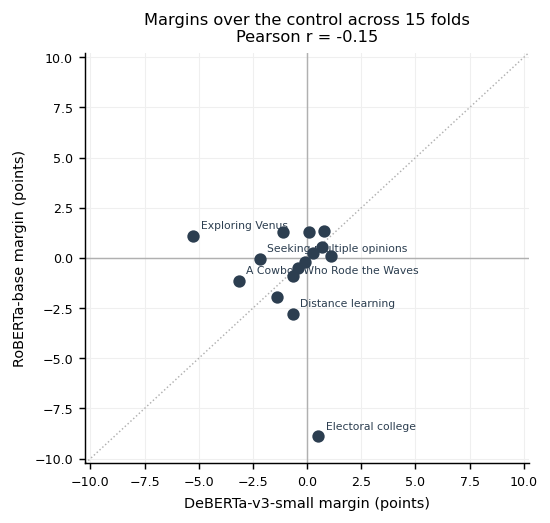

r = -0.152  (near zero means the weak assignment moves with the architecture)


In [6]:

m1, m2 = MODELS[:2]
a = wide[wide.model == m1].set_index('fold')
b = wide[wide.model == m2].set_index('fold')
common = a.index.intersection(b.index)

fig, ax = plt.subplots(figsize=(4.4, 4.1))
x = a.loc[common, 'margin_tfidf'] * 100
y = b.loc[common, 'margin_tfidf'] * 100
ax.axhline(0, color=GREY, lw=0.8); ax.axvline(0, color=GREY, lw=0.8)
ax.scatter(x, y, s=34, color=DARK, zorder=3)

for f in common:
    if abs(x[f]) > 2 or abs(y[f]) > 2:
        ax.annotate(a.loc[f, 'topic'], (x[f], y[f]), fontsize=6,
                    xytext=(4, 4), textcoords='offset points', color=DARK)

lim = max(abs(np.r_[x, y]).max() * 1.15, 3)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.plot([-lim, lim], [-lim, lim], ls=':', color=GREY, lw=0.8, zorder=1)
ax.set_xlabel('%s margin (points)' % NICE[m1])
ax.set_ylabel('%s margin (points)' % NICE[m2])
r = np.corrcoef(x, y)[0, 1]
ax.set_title('Margins over the control across %d folds\nPearson r = %+.2f'
             % (len(common), r))
save(fig, 'rq1_margin_agreement')
plt.show()
print('r = %+.3f  (near zero means the weak assignment moves with the architecture)' % r)

## 3 · Ranking versus threshold

### 3.1 ROC curves per fold


saved  roc_per_fold.pdf  roc_per_fold.png


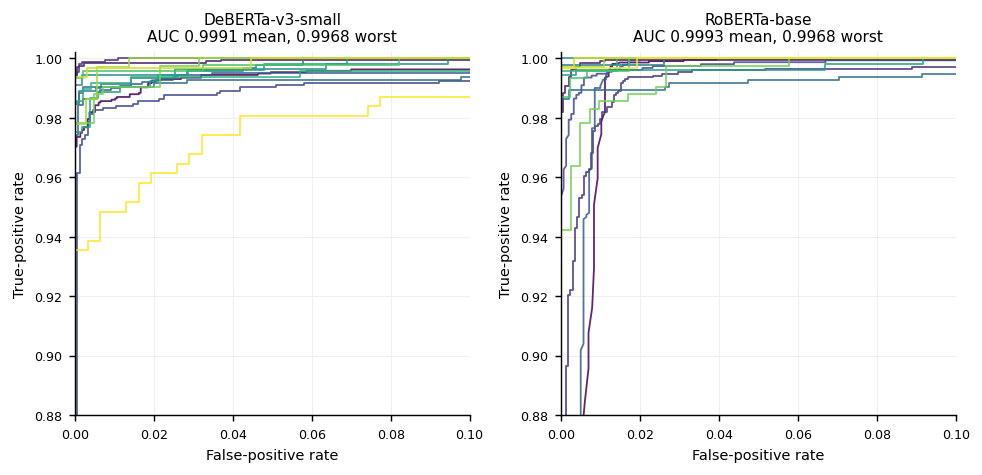

In [7]:

fig, axes = plt.subplots(1, len(MODELS), figsize=(7.6, 3.7))
axes = np.atleast_1d(axes)
cmap = matplotlib.cm.get_cmap('viridis', 15)

for ax, m in zip(axes, MODELS):
    d = preds[preds.model == m]
    if d.empty:
        continue
    aucs = []
    for f, g in d.groupby('fold'):
        fpr, tpr, _ = roc_curve(g.label, g.prob_ai)
        a = auc(fpr, tpr)
        aucs.append(a)
        ax.plot(fpr, tpr, lw=1.0, color=cmap(f), alpha=0.85)
    ax.plot([0, 1], [0, 1], ls='--', color=GREY, lw=0.8)
    ax.set_xlim(0, 0.10); ax.set_ylim(0.88, 1.002)
    ax.set_xlabel('False-positive rate'); ax.set_ylabel('True-positive rate')
    ax.set_title('%s\nAUC %.4f mean, %.4f worst'
                 % (NICE[m], np.mean(aucs), np.min(aucs)), fontsize=8.5)

fig.tight_layout()
save(fig, 'roc_per_fold')
plt.show()

### 3.2 Accuracy against ROC-AUC

The paper's sharpest point: ranking holds on every assignment while
accuracy does not, so what fails is the decision threshold.


saved  roc_auc_vs_accuracy.pdf  roc_auc_vs_accuracy.png


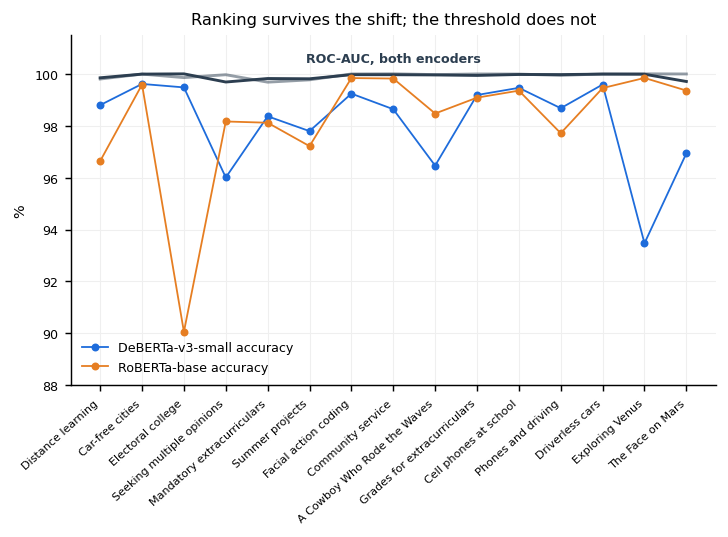

DeBERTa-v3-small AUC min 0.9968  |  accuracy min 0.9347  (Exploring Venus)
RoBERTa-base AUC min 0.9968  |  accuracy min 0.9006  (Electoral college)


In [8]:

fig, ax = plt.subplots(figsize=(6.4, 3.5))
x = np.arange(1, 16)
for m in MODELS:
    d = wide[wide.model == m].sort_values('fold')
    if d.empty:
        continue
    ax.plot(d.fold + 1, d.roc_auc * 100, '-', lw=1.6, color=DARK,
            alpha=1.0 if m == MODELS[0] else 0.5)
    ax.plot(d.fold + 1, d.accuracy * 100, 'o-', lw=1.0, ms=3.4,
            color=C[m], label='%s accuracy' % NICE[m])

ax.text(8, 100.45, 'ROC-AUC, both encoders', fontsize=7, color=DARK,
        ha='center', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([short(t) for t in
                    topics.sort_values('fold').held_out_topic],
                   rotation=42, ha='right', fontsize=6.2)
ax.set_ylabel('%'); ax.set_ylim(88, 101.5)
ax.legend(loc='lower left', frameon=False)
ax.set_title('Ranking survives the shift; the threshold does not')
save(fig, 'roc_auc_vs_accuracy')
plt.show()

for m in MODELS:
    d = wide[wide.model == m]
    if len(d):
        print('%-12s AUC min %.4f  |  accuracy min %.4f  (%s)'
              % (NICE[m], d.roc_auc.min(), d.accuracy.min(),
                 d.loc[d.accuracy.idxmin(), 'topic']))

### 3.3 What a per-fold threshold would recover

Each fold's scores are re-thresholded at the cut point that maximises
accuracy *on that fold*. This is not a usable detector — it needs labels
you would not have — but it separates the loss caused by the threshold
from the loss caused by the representation.


saved  threshold_headroom.pdf  threshold_headroom.png


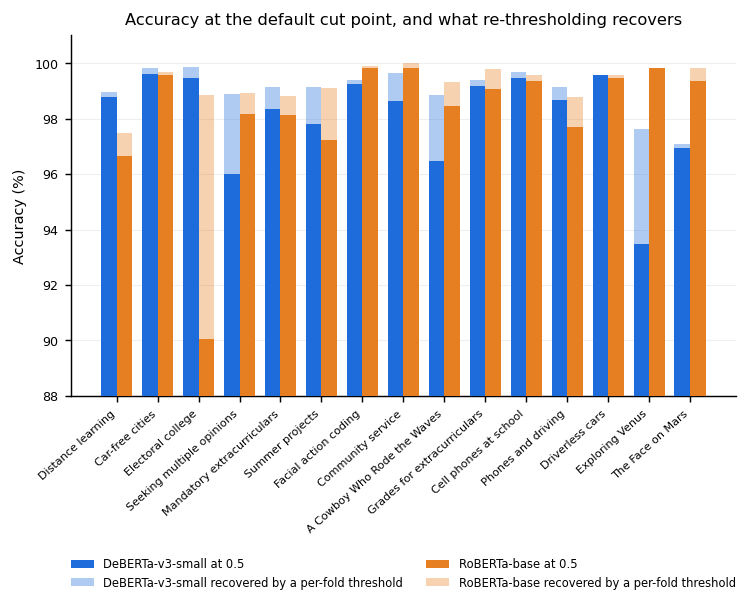

            acc_default  acc_oracle  recovered
model                                         
deberta-v3       0.9811      0.9908     0.0097
roberta          0.9818      0.9930     0.0112

largest single recovery:
     model                       topic  acc_default  acc_oracle  threshold
   roberta           Electoral college     0.900581    0.988372      0.025
deberta-v3             Exploring Venus     0.934713    0.976115      0.985
deberta-v3   Seeking multiple opinions     0.960052    0.988724      0.980
deberta-v3 A Cowboy Who Rode the Waves     0.964627    0.988528      0.990


In [9]:

rows = []
for (m, f), g in preds.groupby(['model', 'fold']):
    y, p = g.label.values, g.prob_ai.values
    grid = np.unique(np.round(np.linspace(0.01, 0.99, 197), 3))
    accs = [( (p >= t).astype(int) == y ).mean() for t in grid]
    best = int(np.argmax(accs))
    rows.append({'model': m, 'fold': f,
                 'acc_default': ((p >= 0.5).astype(int) == y).mean(),
                 'acc_oracle': accs[best], 'threshold': grid[best]})
thr = pd.DataFrame(rows).merge(topics, on='fold')
thr['recovered'] = thr.acc_oracle - thr.acc_default

fig, ax = plt.subplots(figsize=(6.6, 3.6))
w = 0.38
xs = np.arange(15)
for k, m in enumerate(MODELS):
    d = thr[thr.model == m].sort_values('fold')
    if d.empty:
        continue
    ax.bar(xs + (k - 0.5) * w, d.acc_default * 100, w, color=C[m],
           label='%s at 0.5' % NICE[m], zorder=3)
    ax.bar(xs + (k - 0.5) * w, d.recovered * 100, w,
           bottom=d.acc_default * 100, color=C[m], alpha=0.35,
           label='%s recovered by a per-fold threshold' % NICE[m], zorder=3)

ax.set_xticks(xs)
ax.set_xticklabels(thr.sort_values('fold').topic.unique(), rotation=42,
                   ha='right', fontsize=6.2)
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(88, 101)
ax.grid(axis='x', visible=False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.42), ncol=2,
          frameon=False, fontsize=6.4)
ax.set_title('Accuracy at the default cut point, and what re-thresholding recovers')
save(fig, 'threshold_headroom')
plt.show()

print(thr.groupby('model')[['acc_default', 'acc_oracle', 'recovered']].mean().round(4))
print()
print('largest single recovery:')
print(thr.nlargest(4, 'recovered')[['model', 'topic', 'acc_default',
                                    'acc_oracle', 'threshold']].to_string(index=False))

### 3.4 Score distributions on the folds that fail

worst fold per model: {'DeBERTa-v3-small': 13, 'RoBERTa-base': 2}


saved  score_distribution_worst_fold.pdf  score_distribution_worst_fold.png


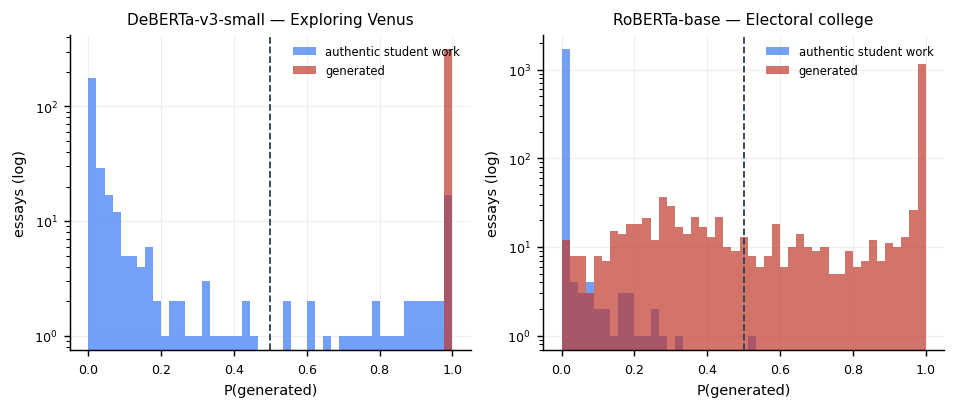

In [10]:

worst = {m: int(wide[wide.model == m].sort_values('accuracy').fold.iloc[0])
         for m in MODELS if len(wide[wide.model == m])}
print('worst fold per model:', {NICE[m]: f for m, f in worst.items()})

fig, axes = plt.subplots(1, len(worst), figsize=(7.4, 3.2))
axes = np.atleast_1d(axes)
bins = np.linspace(0, 1, 46)

for ax, (m, f) in zip(axes, worst.items()):
    g = preds[(preds.model == m) & (preds.fold == f)]
    ax.hist(g[g.label == 0].prob_ai, bins=bins, color='#5B8FF9', alpha=0.85,
            label='authentic student work')
    ax.hist(g[g.label == 1].prob_ai, bins=bins, color=CTRL_TFIDF, alpha=0.7,
            label='generated')
    ax.axvline(0.5, color=DARK, ls='--', lw=1.0)
    ax.set_yscale('log')
    ax.set_xlabel('P(generated)'); ax.set_ylabel('essays (log)')
    ax.set_title('%s — %s' % (NICE[m], g.topic.iloc[0]), fontsize=8.5)
    ax.legend(frameon=False, fontsize=6.4)

fig.tight_layout()
save(fig, 'score_distribution_worst_fold')
plt.show()

### 3.5 Confusion matrices, pooled over the 15 folds

saved  confusion_matrices.pdf  confusion_matrices.png


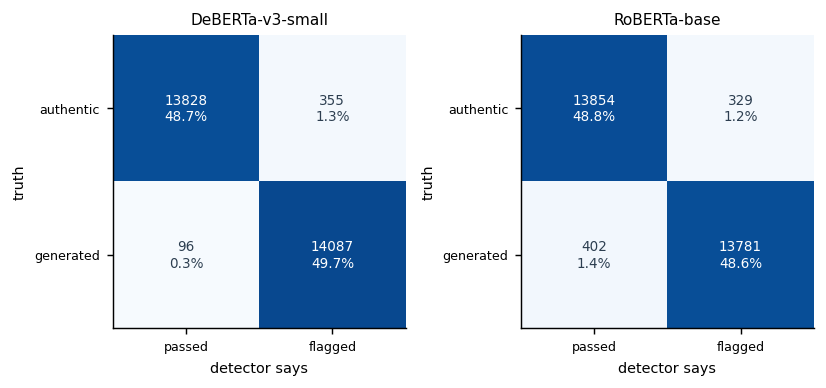

DeBERTa-v3-small 355 false accusations, 96 generated essays passed
RoBERTa-base 329 false accusations, 402 generated essays passed


In [11]:

fig, axes = plt.subplots(1, len(MODELS), figsize=(6.4, 3.0))
axes = np.atleast_1d(axes)

for ax, m in zip(axes, MODELS):
    d = preds[preds.model == m]
    if d.empty:
        continue
    cm = confusion_matrix(d.label, d.pred)
    pct = cm / cm.sum() * 100
    ax.imshow(pct, cmap='Blues', vmin=0, vmax=55)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, '%d\n%.1f%%' % (cm[i, j], pct[i, j]), ha='center',
                    va='center', fontsize=7.5,
                    color='white' if pct[i, j] > 30 else DARK)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['passed', 'flagged'], fontsize=7)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['authentic', 'generated'], fontsize=7)
    ax.set_xlabel('detector says'); ax.set_ylabel('truth')
    ax.grid(False)
    ax.set_title(NICE[m], fontsize=8.5)

fig.tight_layout()
save(fig, 'confusion_matrices')
plt.show()

for m in MODELS:
    d = preds[preds.model == m]
    if len(d):
        fp = ((d.label == 0) & (d.pred == 1)).sum()
        fn = ((d.label == 1) & (d.pred == 0)).sum()
        print('%-12s %d false accusations, %d generated essays passed'
              % (NICE[m], fp, fn))

## 4 · RQ2 — who absorbs the false accusations

Join every authentic essay's verdict to what PERSUADE records about its
writer. Only authentic work can be falsely accused, so only authentic work
enters this section.


In [12]:

import hashlib, re

def norm(s):
    return re.sub(r'\s+', ' ', str(s)).strip().lower()

# rebuild uid -> text from the fold files, then match PERSUADE on exact text
parts = []
for path in glob.glob(os.path.join(LOTO, 'fold_*_test.csv')):
    parts.append(pd.read_csv(path, usecols=['uid', 'text', 'label']))
essays = pd.concat(parts).drop_duplicates('uid')
essays['key'] = essays.text.map(lambda t: hashlib.md5(norm(t).encode()).hexdigest())

pers = pd.read_csv(PERSUADE)
tcol = [c for c in pers.columns if c.lower() in ('full_text', 'text')][0]
pers['key'] = pers[tcol].map(lambda t: hashlib.md5(norm(t).encode()).hexdigest())

gcol = [c for c in pers.columns if 'holistic' in c.lower()][0]
ecol = [c for c in pers.columns if 'ell' in c.lower() or 'english' in c.lower()]
keep = ['key', gcol] + ecol[:1]
pers = pers[keep].drop_duplicates('key')
pers = pers.rename(columns={gcol: 'grade'})
if ecol:
    pers = pers.rename(columns={ecol[0]: 'ell'})

authentic = preds[preds.label == 0].merge(
    essays[['uid', 'key']], on='uid', how='left').merge(pers, on='key', how='left')

print('authentic verdicts:', len(authentic))
print('matched to a grade :', int(authentic.grade.notna().sum()),
      '(%.1f%%)' % (100 * authentic.grade.notna().mean()))

authentic verdicts: 28366
matched to a grade : 26406 (93.1%)


saved  rq2_false_accusations.pdf  rq2_false_accusations.png


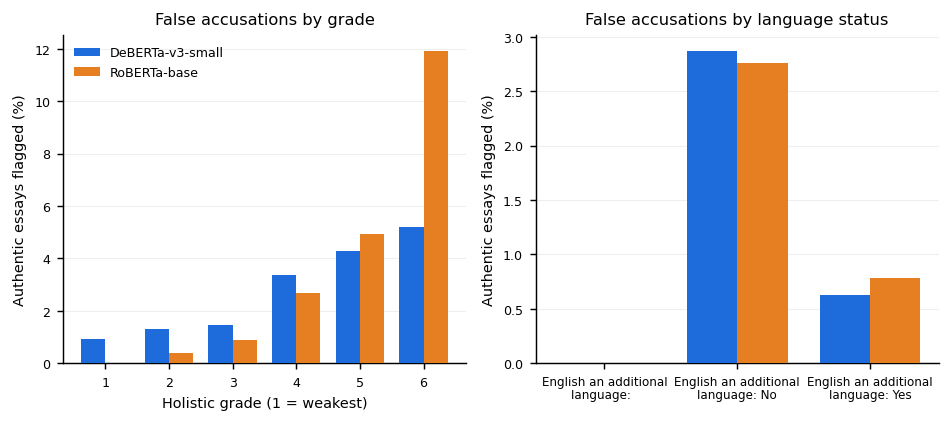

DeBERTa-v3-small grade 1: 0.92%  ->  grade 6: 5.18%   (5.6x)


In [13]:

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.3))

# --- by holistic grade -------------------------------------------------
ax = axes[0]
g = (authentic.dropna(subset=['grade'])
     .groupby(['model', 'grade'])
     .agg(fpr=('pred', 'mean'), n=('pred', 'size')).reset_index())
grades = sorted(g.grade.unique())
w = 0.38
for k, m in enumerate(MODELS):
    d = g[g.model == m].set_index('grade').reindex(grades)
    if d.fpr.isna().all():
        continue
    ax.bar(np.arange(len(grades)) + (k - 0.5) * w, d.fpr * 100, w,
           color=C[m], label=NICE[m], zorder=3)
ax.set_xticks(np.arange(len(grades)))
ax.set_xticklabels([int(x) for x in grades])
ax.set_xlabel('Holistic grade (1 = weakest)')
ax.set_ylabel('Authentic essays flagged (%)')
ax.grid(axis='x', visible=False)
ax.legend(frameon=False)
ax.set_title('False accusations by grade')

# --- by English-language status ---------------------------------------
ax = axes[1]
if 'ell' in authentic.columns:
    e = (authentic.dropna(subset=['ell'])
         .groupby(['model', 'ell'])
         .agg(fpr=('pred', 'mean'), n=('pred', 'size')).reset_index())
    cats = sorted(e.ell.unique())
    for k, m in enumerate(MODELS):
        d = e[e.model == m].set_index('ell').reindex(cats)
        if d.fpr.isna().all():
            continue
        ax.bar(np.arange(len(cats)) + (k - 0.5) * w, d.fpr * 100, w,
               color=C[m], label=NICE[m], zorder=3)
    ax.set_xticks(np.arange(len(cats)))
    ax.set_xticklabels(['English an additional\nlanguage: %s' % c for c in cats],
                       fontsize=6.6)
    ax.set_ylabel('Authentic essays flagged (%)')
    ax.grid(axis='x', visible=False)
    ax.set_title('False accusations by language status')
else:
    ax.set_visible(False)

fig.tight_layout()
save(fig, 'rq2_false_accusations')
plt.show()

for m in MODELS:
    d = g[g.model == m].set_index('grade')
    if len(d) and d.fpr.iloc[0] > 0:
        print('%-12s grade %d: %.2f%%  ->  grade %d: %.2f%%   (%.1fx)'
              % (NICE[m], grades[0], d.fpr.iloc[0] * 100,
                 grades[-1], d.fpr.iloc[-1] * 100, d.fpr.iloc[-1] / d.fpr.iloc[0]))

### 4.1 The formality mechanism

Within each grade band, are the essays the detector flagged the more
formally written ones? `results/rq2_markers_within_grade.csv` holds this
for DeBERTa; the cell recomputes it for any model whose predictions are
present.


     model  grade  n_flagged  n_passed  flagged   passed  difference
deberta-v3      2         30      2284 1.560961 0.978894    0.582067
deberta-v3      3         56      3749 1.647252 1.182621    0.464630
deberta-v3      4        129      3718 1.694315 1.416055    0.278260
deberta-v3      5         93      2073 2.072225 1.456713    0.615512
deberta-v3      6         33       604 1.663876 1.578231    0.085645
   roberta      3         33      3772 1.482738 1.186894    0.295844
   roberta      4        103      3744 2.223084 1.403441    0.819643
   roberta      5        107      2059 2.047216 1.453828    0.593388
   roberta      6         76       561 1.983731 1.528334    0.455396


saved  rq2_marker_density.pdf  rq2_marker_density.png


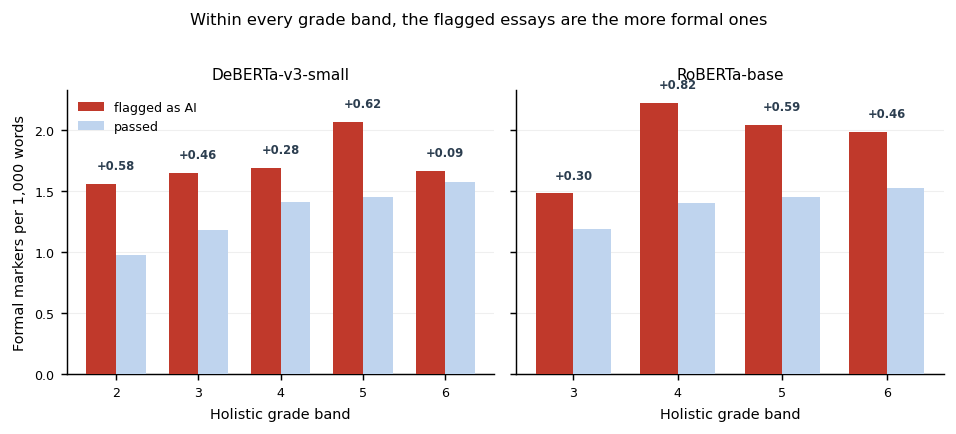

In [14]:

MARKERS = ['however', 'moreover', 'furthermore', 'therefore', 'consequently',
           'nevertheless', 'nonetheless', 'thus', 'hence', 'additionally',
           'specifically', 'particularly', 'significantly', 'ultimately',
           'essentially', 'notably', 'importantly', 'subsequently',
           'accordingly', 'conversely', 'in conclusion', 'in addition',
           'for instance', 'as a result', 'in contrast', 'on the other hand']

def marker_density(text):
    t = ' ' + norm(text) + ' '
    words = max(len(t.split()), 1)
    hits = sum(t.count(' ' + m + ' ') if ' ' not in m else t.count(m)
               for m in MARKERS)
    return hits / words * 1000

txt = essays[['uid', 'text']].copy()
txt['density'] = txt.text.map(marker_density)
auth = authentic.merge(txt[['uid', 'density']], on='uid', how='left')

rows = []
for (m, gr), d in auth.dropna(subset=['grade']).groupby(['model', 'grade']):
    flagged, passed = d[d.pred == 1], d[d.pred == 0]
    if len(flagged) >= 20 and len(passed) >= 20:
        rows.append({'model': m, 'grade': int(gr),
                     'n_flagged': len(flagged), 'n_passed': len(passed),
                     'flagged': flagged.density.mean(),
                     'passed': passed.density.mean()})
mk = pd.DataFrame(rows)
mk['difference'] = mk.flagged - mk.passed
print(mk.to_string(index=False))

fig, axes = plt.subplots(1, len(MODELS), figsize=(7.4, 3.2), sharey=True)
axes = np.atleast_1d(axes)
for ax, m in zip(axes, MODELS):
    d = mk[mk.model == m].sort_values('grade')
    if d.empty:
        ax.set_visible(False)
        continue
    x = np.arange(len(d)); w = 0.36
    ax.bar(x - w / 2, d.flagged, w, color=CTRL_TFIDF, label='flagged as AI', zorder=3)
    ax.bar(x + w / 2, d.passed,  w, color='#BFD4EE', label='passed', zorder=3)
    for i, r in enumerate(d.itertuples()):
        ax.text(i, max(r.flagged, r.passed) + 0.12, '+%.2f' % r.difference,
                ha='center', fontsize=6.4, color=DARK, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(d.grade)
    ax.set_xlabel('Holistic grade band')
    ax.grid(axis='x', visible=False)
    ax.set_title(NICE[m], fontsize=8.5)
axes[0].set_ylabel('Formal markers per 1,000 words')
axes[0].legend(frameon=False, loc='upper left')
fig.suptitle('Within every grade band, the flagged essays are the more formal ones',
             fontsize=9, y=1.02)
fig.tight_layout()
save(fig, 'rq2_marker_density')
plt.show()

### 4.2 The corpus audit

Not a detector result, but the paper's third finding and the only figure
that comes from the dataset rather than a model: what the essays a
prompt-vocabulary recovery labels "car usage" actually answer.


saved  corpus_audit_labels.pdf  corpus_audit_labels.png


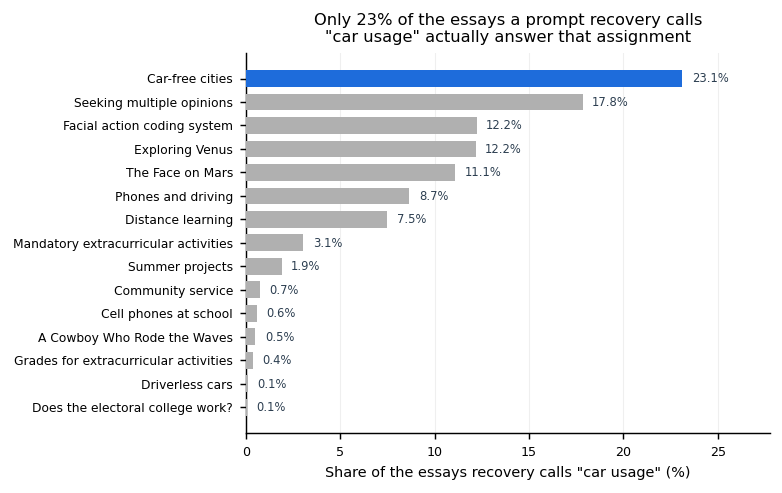

n = 8576  spans 15 assignments


In [15]:

prompts_csv = os.path.join(DATA, 'llm_detect_prompts.csv')
if os.path.exists(prompts_csv):
    pr = pd.read_csv(prompts_csv)
    pr['key'] = pr.text.map(lambda t: hashlib.md5(norm(t).encode()).hexdigest())

    alltxt = []
    for path in glob.glob(os.path.join(LOTO, 'fold_00_*.csv')):
        alltxt.append(pd.read_csv(path, usecols=['text', 'topic']))
    tt = pd.concat(alltxt)
    tt['key'] = tt.text.map(lambda t: hashlib.md5(norm(t).encode()).hexdigest())
    tt = tt.drop_duplicates('key')

    jn = pr.merge(tt[['key', 'topic']], on='key', how='inner')
    car = jn[jn.prompt_id == 0]
    pct = car.topic.value_counts() / len(car) * 100

    fig, ax = plt.subplots(figsize=(5.2, 3.8))
    yy = np.arange(len(pct))[::-1]
    cols = ['#1E6CDB' if t == 'Car-free cities' else GREY for t in pct.index]
    ax.barh(yy, pct.values, color=cols, height=0.72, zorder=3)
    for y_, v in zip(yy, pct.values):
        ax.text(v + 0.5, y_, '%.1f%%' % v, va='center', fontsize=6.4, color=DARK)
    ax.set_yticks(yy)
    ax.set_yticklabels([t.replace('"', '') for t in pct.index], fontsize=6.8)
    ax.set_xlabel('Share of the essays recovery calls "car usage" (%)')
    ax.set_xlim(0, pct.max() * 1.2)
    ax.grid(axis='y', visible=False)
    ax.set_title('Only %.0f%% of the essays a prompt recovery calls\n'
                 '"car usage" actually answer that assignment' % pct.iloc[0])
    save(fig, 'corpus_audit_labels')
    plt.show()
    print('n =', len(car), ' spans', len(pct), 'assignments')
else:
    print('data/llm_detect_prompts.csv not found — skipping')

## 5 · Explainability

### 5.1 The LIME tokens already computed

`results/rq2_lime_tokens.csv` was produced during the main study for
DeBERTa. This plots it without recomputing anything.


saved  lime_tokens_existing.pdf  lime_tokens_existing.png


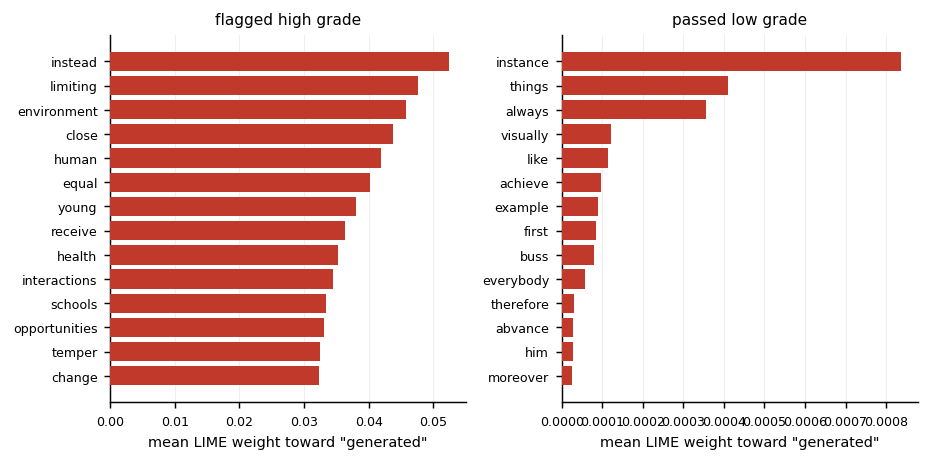

In [16]:

lime_path = os.path.join(RESULTS, 'rq2_lime_tokens.csv')
if os.path.exists(lime_path):
    lt = pd.read_csv(lime_path)
    agg = (lt.groupby(['group', 'token'])
           .agg(weight=('weight', 'mean'), n=('weight', 'size'))
           .reset_index())
    groups = agg.group.unique()

    fig, axes = plt.subplots(1, len(groups), figsize=(3.6 * len(groups), 3.6))
    axes = np.atleast_1d(axes)
    for ax, grp in zip(axes, groups):
        d = agg[agg.group == grp].nlargest(14, 'weight').sort_values('weight')
        ax.barh(np.arange(len(d)), d.weight, color=CTRL_TFIDF, zorder=3)
        ax.set_yticks(np.arange(len(d))); ax.set_yticklabels(d.token, fontsize=7)
        ax.set_xlabel('mean LIME weight toward "generated"')
        ax.grid(axis='y', visible=False)
        ax.set_title(grp.replace('_', ' '), fontsize=8.5)
    fig.tight_layout()
    save(fig, 'lime_tokens_existing')
    plt.show()
else:
    print('no rq2_lime_tokens.csv — run section 5.2 to compute one')

### 5.2 Fresh LIME, either encoder (optional, trains a model)

The sweep deleted its checkpoints, so explaining a fold means fine-tuning
it again. Set `RUN_LIME = True` and pick a fold and model. On a GPU this
is roughly the cost of one fold of the main study.


In [17]:

RUN_LIME   = False          # set True to actually run this section
LIME_MODEL = 'roberta'      # 'roberta' or 'deberta-v3'
LIME_FOLD  = 2              # 2 = RoBERTa's worst fold, 13 = DeBERTa's
N_EXPLAIN  = 60             # authentic essays the detector flagged
N_SAMPLES  = 1000           # LIME perturbations per essay

HF_ID = {'deberta-v3': 'microsoft/deberta-v3-small',
         'roberta': 'roberta-base'}
MAX_LEN, LR, BATCH, EPOCHS = 256, 2e-5, 8, 2
print('RUN_LIME =', RUN_LIME)

RUN_LIME = False


In [18]:

if RUN_LIME:
    import torch
    from torch.utils.data import Dataset, DataLoader
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                              get_linear_schedule_with_warmup)

    dev = 'cuda' if torch.cuda.is_available() else 'cpu'
    print('device:', dev)

    tr = pd.read_csv(os.path.join(LOTO, 'fold_%02d_train.csv' % LIME_FOLD))
    va = pd.read_csv(os.path.join(LOTO, 'fold_%02d_val.csv' % LIME_FOLD))
    tok = AutoTokenizer.from_pretrained(HF_ID[LIME_MODEL])

    class DS(Dataset):
        def __init__(self, df):
            self.t = list(df.text); self.y = list(df.label)
        def __len__(self):
            return len(self.y)
        def __getitem__(self, i):
            e = tok(self.t[i], truncation=True, max_length=MAX_LEN,
                    padding='max_length', return_tensors='pt')
            return ({k: v.squeeze(0) for k, v in e.items()},
                    torch.tensor(self.y[i]))

    model = AutoModelForSequenceClassification.from_pretrained(
        HF_ID[LIME_MODEL], num_labels=2).to(dev)
    dl = DataLoader(DS(tr), batch_size=BATCH, shuffle=True)
    opt = torch.optim.AdamW(model.parameters(), lr=LR)
    sch = get_linear_schedule_with_warmup(opt, 0, len(dl) * EPOCHS)

    model.train()
    for ep in range(EPOCHS):
        for i, (xb, yb) in enumerate(dl):
            xb = {k: v.to(dev) for k, v in xb.items()}
            loss = model(**xb, labels=yb.to(dev)).loss
            loss.backward(); opt.step(); sch.step(); opt.zero_grad()
            if i % 200 == 0:
                print('epoch %d step %4d/%d loss %.4f' % (ep, i, len(dl), loss.item()))
    model.eval()
    print('trained')
else:
    print('skipped — set RUN_LIME = True above')

skipped — set RUN_LIME = True above


In [19]:

if RUN_LIME:
    from lime.lime_text import LimeTextExplainer

    def predict_proba(texts):
        out = []
        for i in range(0, len(texts), 32):
            e = tok(list(texts[i:i + 32]), truncation=True, max_length=MAX_LEN,
                    padding=True, return_tensors='pt').to(dev)
            with torch.no_grad():
                out.append(torch.softmax(model(**e).logits, -1).cpu().numpy())
        return np.vstack(out)

    te = pd.read_csv(os.path.join(LOTO, 'fold_%02d_test.csv' % LIME_FOLD))
    auth_fold = te[te.label == 0].copy()
    auth_fold['prob_ai'] = predict_proba(auth_fold.text.values)[:, 1]
    flagged = auth_fold[auth_fold.prob_ai >= 0.5].nlargest(N_EXPLAIN, 'prob_ai')
    print('authentic essays flagged on this fold:', len(flagged))

    expl = LimeTextExplainer(class_names=['student', 'generated'])
    rows = []
    for j, (_, r) in enumerate(flagged.iterrows()):
        ex = expl.explain_instance(r.text, predict_proba,
                                   num_features=12, num_samples=N_SAMPLES)
        for token, w in ex.as_list():
            if w > 0:
                rows.append({'model': LIME_MODEL, 'fold': LIME_FOLD,
                             'uid': r.uid, 'token': token.lower(), 'weight': w})
        if j % 10 == 0:
            print('explained %d/%d' % (j, len(flagged)))

    fresh = pd.DataFrame(rows)
    out = os.path.join(RESULTS, 'lime_%s_fold%02d.csv' % (LIME_MODEL, LIME_FOLD))
    fresh.to_csv(out, index=False)
    print('wrote', out)
else:
    print('skipped')

skipped


In [20]:

if RUN_LIME and len(fresh):
    agg = (fresh.groupby('token')
           .agg(weight=('weight', 'mean'), n=('weight', 'size'))
           .query('n >= 3').nlargest(18, 'weight').sort_values('weight'))

    fig, ax = plt.subplots(figsize=(4.6, 4.0))
    ax.barh(np.arange(len(agg)), agg.weight, color=C[LIME_MODEL], zorder=3)
    ax.set_yticks(np.arange(len(agg))); ax.set_yticklabels(agg.index, fontsize=7)
    ax.set_xlabel('mean LIME weight toward "generated"')
    ax.grid(axis='y', visible=False)
    ax.set_title('%s — words that pushed authentic essays\ntoward the generated class (%s)'
                 % (NICE[LIME_MODEL], short(topics.set_index('fold')
                    .loc[LIME_FOLD, 'held_out_topic'])), fontsize=8.5)
    save(fig, 'lime_%s_fold%02d' % (LIME_MODEL, LIME_FOLD))
    plt.show()
    print(agg.sort_values('weight', ascending=False).head(12).to_string())
else:
    print('skipped')

skipped


## 6 · Summary table and export

A single table of everything, written next to the figures.


In [21]:

summary = wide[['model', 'fold', 'held_out_topic', 'n_test', 'accuracy',
                'recall', 'roc_auc', 'fpr', 'fnr', 'tfidf', 'length',
                'margin_tfidf', 'margin_length']].copy()
summary.to_csv(os.path.join(FIGS, 'summary_both_encoders.csv'), index=False)

show = summary.copy()
for c in ['accuracy', 'recall', 'roc_auc', 'fpr', 'fnr', 'tfidf', 'length',
          'margin_tfidf', 'margin_length']:
    show[c] = (show[c] * 100).round(2)
print(show.to_string(index=False))

print()
print('=== per model ===')
print(summary.groupby('model').agg(
    mean_acc=('accuracy', 'mean'), min_acc=('accuracy', 'min'),
    mean_auc=('roc_auc', 'mean'), min_auc=('roc_auc', 'min'),
    mean_margin=('margin_tfidf', 'mean'),
    folds_above_control=('margin_tfidf', lambda s: int((s > 0).sum())),
).round(4).to_string())

print()
print('figures written to', FIGS)
for f in sorted(os.listdir(FIGS)):
    if f.endswith('.pdf'):
        print('  ', f)

     model  fold                        held_out_topic  n_test  accuracy  recall  roc_auc   fpr   fnr  tfidf  length  margin_tfidf  margin_length
deberta-v3     0                     Distance learning    4314     98.79   98.70    99.85  1.11  1.30  99.44   76.37         -0.65          22.43
deberta-v3     1                       Car-free cities    4102     99.61   99.85    99.99  0.63  0.15  99.32   54.97          0.29          44.64
deberta-v3     2      Does the electoral college work?    3440     99.48   99.94   100.00  0.99  0.06  98.95   55.00          0.52          44.48
deberta-v3     3             Seeking multiple opinions    3104     96.01   99.16    99.68  7.15  0.84  98.20   71.91         -2.19          24.10
deberta-v3     4  Mandatory extracurricular activities    2812     98.36   99.43    99.82  2.70  0.57  99.00   74.25         -0.64          24.11
deberta-v3     5                       Summer projects    1902     97.79   99.26    99.81  3.68  0.74  99.16   84.66        